### check cryosat-2 sarin l2 data

In [3]:
import numpy as np
import xarray as xr
import geopandas as gpd
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from utils.utils import hz01_hz20, dt64_to_dyr


In [4]:
path_cryo2_l2 = 'data/cryosat-2/CS_LTA__SIR_SIN_2__20150508T035141_20150508T035526_E001.nc'
path_namco = 'data/vector/namco_lake.gpkg'


In [5]:
cryo2_l2 = xr.open_dataset(path_cryo2_l2)
lake_gdf = gpd.read_file(path_namco)


In [6]:
cryo2_l2


<xarray.Dataset> Size: 1MB
Dimensions:                           (time_cor_01: 257, time_20_ku: 5136)
Coordinates:
  * time_cor_01                       (time_cor_01) datetime64[ns] 2kB 2015-0...
  * time_20_ku                        (time_20_ku) datetime64[ns] 41kB 2015-0...
    lat_01                            (time_cor_01) float64 2kB ...
    lat_poca_20_ku                    (time_20_ku) float64 41kB ...
    lon_01                            (time_cor_01) float64 2kB ...
    lon_poca_20_ku                    (time_20_ku) float64 41kB ...
Data variables: (12/54)
    alt_01                            (time_cor_01) float64 2kB ...
    echo_avg_numval_20_ku             (time_20_ku) float32 21kB ...
    flag_cor_applied_20_ku            (time_20_ku) float64 41kB ...
    flag_cor_err_01                   (time_cor_01) float64 2kB ...
    flag_instr_conf_rx_str_in_use_01  (time_cor_01) float32 1kB ...
    flag_instr_mode_op_20_ku          (time_20_ku) float32 21kB ...
    ...                                ...
    ssha_interp_20_ku                 (time_20_ku) float64 41kB ...
    ssha_interp_numval_20_ku          (time_20_ku) float32 21kB ...
    ssha_interp_rms_20_ku             (time_20_ku) float64 41kB ...
    surf_type_20_ku                   (time_20_ku) float32 21kB ...
    swh_ocean_01_ku                   (time_cor_01) float64 2kB ...
    wind_speed_alt_01_ku              (time_cor_01) float64 2kB ...
Attributes: (12/102)
    product_name:                 CS_LTA__SIR_SIN_2__20150508T035141_20150508...
    processing_stage:             LTA_
    reference_document:           CS-RS-ACS-ESL-5265 2.1
    doi:                          10.5270/CR2-65cff05
    acquisition_station:          Kiruna              
    mission:                      Cryosat
    ...                           ...
    xref_surf_type:               CS_OPER_AUX_LS_MAP_00000000T000000_99999999...
    xref_tidal_load:              CS_OPER_AUX_TDLOAD_00000000T000000_99999999...
    xref_u_wind:                  CS_OPER_AUX_U_WIND_20150508T000000_20150508...
    xref_uso:                     CS_OPER_AUX_DORUSO_20100411T040029_20211117...
    xref_v_wind:                  CS_OPER_AUX_V_WIND_20150508T000000_20150508...
    xref_wet_trop:                CS_OPER_AUX_WETTRP_20150508T000000_20150508...

In [7]:
# select 20Hz points within the lake polygon
pts_20hz = gpd.GeoDataFrame(
  geometry=gpd.points_from_xy(cryo2_l2['lon_poca_20_ku'].values, cryo2_l2['lat_poca_20_ku'].values),
  crs=(lake_gdf.crs or "EPSG:4326")
  )
mask_in_lake = pts_20hz.within(lake_gdf.geometry.union_all()).to_numpy()
cryo2_l2_lake = cryo2_l2.isel(time_20_ku=np.where(mask_in_lake)[0])
cryo2_l2_lake


<xarray.Dataset> Size: 83kB
Dimensions:                           (time_cor_01: 257, time_20_ku: 99)
Coordinates:
  * time_cor_01                       (time_cor_01) datetime64[ns] 2kB 2015-0...
  * time_20_ku                        (time_20_ku) datetime64[ns] 792B 2015-0...
    lat_01                            (time_cor_01) float64 2kB ...
    lat_poca_20_ku                    (time_20_ku) float64 792B 30.62 ... 30.89
    lon_01                            (time_cor_01) float64 2kB ...
    lon_poca_20_ku                    (time_20_ku) float64 792B 90.73 ... 90.69
Data variables: (12/54)
    alt_01                            (time_cor_01) float64 2kB ...
    echo_avg_numval_20_ku             (time_20_ku) float32 396B ...
    flag_cor_applied_20_ku            (time_20_ku) float64 792B ...
    flag_cor_err_01                   (time_cor_01) float64 2kB ...
    flag_instr_conf_rx_str_in_use_01  (time_cor_01) float32 1kB ...
    flag_instr_mode_op_20_ku          (time_20_ku) float32 396B ...
    ...                                ...
    ssha_interp_20_ku                 (time_20_ku) float64 792B ...
    ssha_interp_numval_20_ku          (time_20_ku) float32 396B ...
    ssha_interp_rms_20_ku             (time_20_ku) float64 792B ...
    surf_type_20_ku                   (time_20_ku) float32 396B ...
    swh_ocean_01_ku                   (time_cor_01) float64 2kB ...
    wind_speed_alt_01_ku              (time_cor_01) float64 2kB ...
Attributes: (12/102)
    product_name:                 CS_LTA__SIR_SIN_2__20150508T035141_20150508...
    processing_stage:             LTA_
    reference_document:           CS-RS-ACS-ESL-5265 2.1
    doi:                          10.5270/CR2-65cff05
    acquisition_station:          Kiruna              
    mission:                      Cryosat
    ...                           ...
    xref_surf_type:               CS_OPER_AUX_LS_MAP_00000000T000000_99999999...
    xref_tidal_load:              CS_OPER_AUX_TDLOAD_00000000T000000_99999999...
    xref_u_wind:                  CS_OPER_AUX_U_WIND_20150508T000000_20150508...
    xref_uso:                     CS_OPER_AUX_DORUSO_20100411T040029_20211117...
    xref_v_wind:                  CS_OPER_AUX_V_WIND_20150508T000000_20150508...
    xref_wet_trop:                CS_OPER_AUX_WETTRP_20150508T000000_20150508...

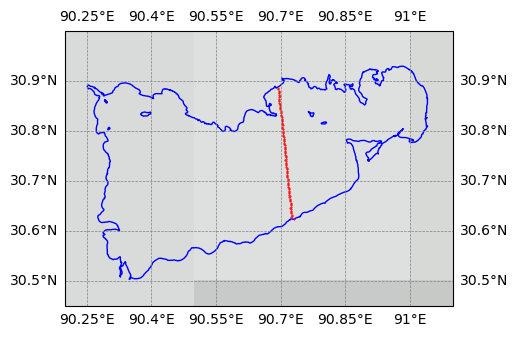

In [8]:
proj = ccrs.PlateCarree(central_longitude=0.0)
fig = plt.figure(figsize=(5,5))
ax = fig.add_subplot(111, projection=proj)
ax.set_extent([90.2, 91.1, 30.45, 31], crs=ccrs.PlateCarree())
ax.stock_img()
ax.plot(cryo2_l2_lake['lon_poca_20_ku'][:], cryo2_l2_lake['lat_poca_20_ku'][:], 
                          marker='.', markersize=1, linewidth=0.0, color='red')
lake_gdf.plot(ax=ax, facecolor='none', edgecolor='blue', linewidth=1)
ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', linestyle='--')
plt.show()



In [9]:
time_01 = dt64_to_dyr(cryo2_l2_lake['time_cor_01'].values, precision='us')
time_20 = dt64_to_dyr(cryo2_l2_lake['time_20_ku'].values, precision='us')
cryo2_l2_alt_20 = hz01_hz20(data_01hz=cryo2_l2_lake['alt_01'].values, 
                          time_01hz=time_01, 
                          time_20hz=time_20, 
                          interp_method='linear'
                          )


In [10]:
geophy_cor_01hz = cryo2_l2_lake['iono_cor_01'].values + cryo2_l2_lake['load_tide_01'].values + \
                  cryo2_l2_lake['solid_earth_tide_01'].values + cryo2_l2_lake['pole_tide_01'].values + \
                  cryo2_l2_lake['mod_dry_tropo_cor_01'].values + cryo2_l2_lake['mod_wet_tropo_cor_01'].values
geophy_cor_20hz = hz01_hz20(data_01hz=geophy_cor_01hz, 
                            time_01hz=time_01, 
                            time_20hz=time_20, 
                            interp_method='linear'
                            ) 


In [11]:
### geophysical corrected height at 20Hz
ht_20hz_cor = cryo2_l2_alt_20 - cryo2_l2_lake['range_1_20_ku'].values - geophy_cor_20hz


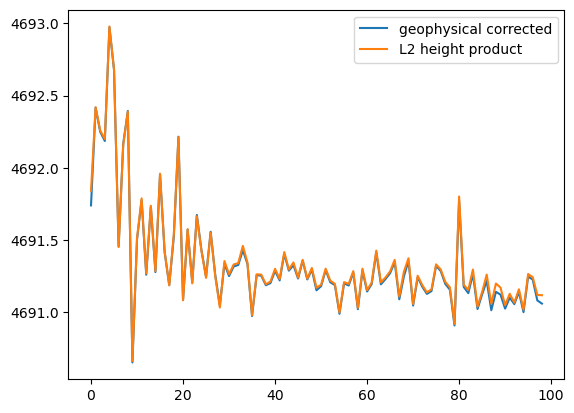

In [12]:
## comparison between geophysical corrected height and L2 height product
plt.plot(ht_20hz_cor, label='geophysical corrected')
plt.plot(cryo2_l2_lake['height_1_20_ku'].values, label='L2 height product')
plt.legend()
